Confusion Matrix:
[[752   0]
 [ 22 321]]
Accuracy without rounding = 0.9799086757990868
Accuracy rounded = 0.98
F1 Score without rounding = 0.966867469879518
F1 Score rounded = 0.97


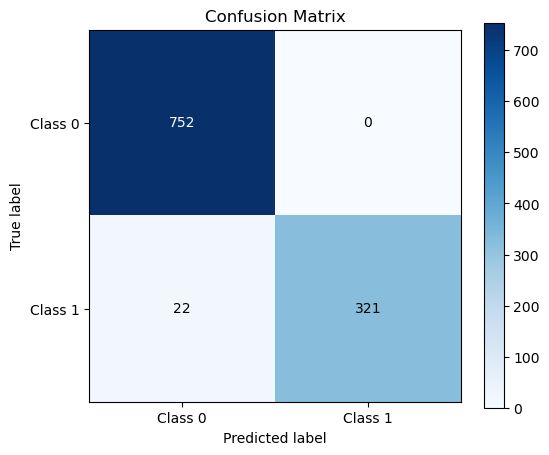

In [1]:
#question 1 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score


data = pd.read_csv("daily-minimum-temperatures-in-me (1).csv")

data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

data["Daily minimum temperatures"] = pd.to_numeric(
    data["Daily minimum temperatures"], errors="coerce"
)

data = data.dropna()


scaler = MinMaxScaler()

data["temp_normalized"] = scaler.fit_transform(
    data[["Daily minimum temperatures"]]
)


y = (data["temp_normalized"] >= 0.5).astype(int)

X = data[["temp_normalized"]]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


model = LogisticRegression()

model.fit(X_train, y_train)


y_prob = model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= 0.5).astype(int)


cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)


print("Confusion Matrix:")
print(cm)

print("Accuracy without rounding =", accuracy)
print("Accuracy rounded =", round(accuracy, 2))

print("F1 Score without rounding =", f1)
print("F1 Score rounded =", round(f1, 2))


fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)

ax.figure.colorbar(im, ax=ax)

class_names = ["Class 0", "Class 1"]

ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    ylabel="True label",
    xlabel="Predicted label",
    title="Confusion Matrix"
)


thresh = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.show()

Confusion Matrix:
[[752   0]
 [ 79 264]]
Accuracy without rounding = 0.9278538812785389
Accuracy rounded = 0.93
F1 Score without rounding = 0.8698517298187809
F1 Score rounded = 0.87


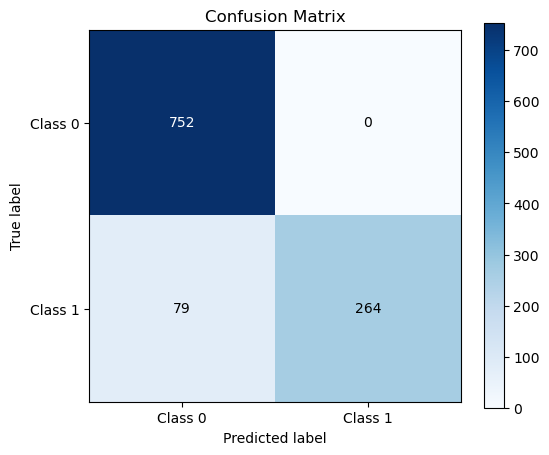

In [2]:
#question 2 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


data = pd.read_csv("daily-minimum-temperatures-in-me (1).csv")

data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

data["Daily minimum temperatures"] = pd.to_numeric(
    data["Daily minimum temperatures"], errors="coerce"
)

data = data.dropna()


temp = data["Daily minimum temperatures"].values

temp_min = np.min(temp)
temp_max = np.max(temp)

temp_normalized = (temp - temp_min) / (temp_max - temp_min)


y = (temp_normalized >= 0.5).astype(int)

X = temp_normalized.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)


class LogisticRegressionScratch:

    def __init__(self, lr=0.1, epochs=3000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):

            linear_model = np.dot(X, self.w) + self.b

            y_prob = self.sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_prob - y))
            db = (1 / n_samples) * np.sum(y_prob - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):

        linear_model = np.dot(X, self.w) + self.b

        y_prob = self.sigmoid(linear_model)

        return (y_prob >= 0.5).astype(int)


model = LogisticRegressionScratch(lr=0.1, epochs=3000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


TP = int(np.sum((y_test == 1) & (y_pred == 1)))
TN = int(np.sum((y_test == 0) & (y_pred == 0)))
FP = int(np.sum((y_test == 0) & (y_pred == 1)))
FN = int(np.sum((y_test == 1) & (y_pred == 0)))


cm = np.array([[TN, FP],
               [FN, TP]])


print("Confusion Matrix:")
print(cm)


if (TP + FP) != 0:
    precision = TP / (TP + FP)
else:
    precision = 0


if (TP + FN) != 0:
    recall = TP / (TP + FN)
else:
    recall = 0


if (precision + recall) != 0:
    f1 = 2 * (precision * recall) / (precision + recall)
else:
    f1 = 0


accuracy = (TP + TN) / len(y_test)


print("Accuracy without rounding =", accuracy)
print("Accuracy rounded =", round(accuracy, 2))

print("F1 Score without rounding =", f1)
print("F1 Score rounded =", round(f1, 2))


fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)

ax.figure.colorbar(im, ax=ax)

class_names = ["Class 0", "Class 1"]

ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    ylabel="True label",
    xlabel="Predicted label",
    title="Confusion Matrix"
)


thresh = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.show()